In [ ]:
# BAGIAN 1: Install & Import
!pip install nltk scikit-learn pandas requests

import requests
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
#PART 2 - Retrieve Dataset Using Python
import requests
import pandas as pd
from google.colab import userdata

API_TOKEN = userdata.get('API_TOKEN')
DATASET_URL = userdata.get('DATASET_URL')

response = requests.get(DATASET_URL,
                        params={"token": API_TOKEN, "clean": "true", "limit": 100000})

data = response.json()

df = pd.DataFrame(data)

print("Total rows:", len(df))
df.head()

Total rows: 500


,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
0,False,/9n2tJBplPbgR2ca05hS5CKXwP2c.jpg,"[10751, 35, 12, 14, 16]",502356,en,The Super Mario Bros. Movie,"While working underground to fix a water main,...",339.0067,/qNBAXBIQlnOThrVvA6mA2B5ggV6.jpg,2023-04-05,The Super Mario Bros. Movie,False,7.588,10464
1,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,"[10751, 35, 12, 14, 16]",1226863,en,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,274.0615,/eJGWx219ZcEMVQJhAgMiqo8tYY.jpg,2026-04-01,The Super Mario Galaxy Movie,False,6.900,379
2,False,/l8rKKMU2M9dDULO9CEtDNdWAEUJ.jpg,"[878, 27, 14]",1159831,en,The Bride!,A lonely Frankenstein travels to 1930s Chicago...,182.3159,/lV8YHwGkYZsm6EfIqnhaSz2avKt.jpg,2026-03-04,The Bride!,False,6.299,281
3,False,/gM1kQRPwOVW1Eos5tVWqcYmHR5S.jpg,"[27, 9648]",1470130,en,The Mortuary Assistant,"Rebecca Owens, a recent mortuary science gradu...",205.6820,/72AoFPC5TY4DfJwXXS9rPwPeReD.jpg,2026-02-13,The Mortuary Assistant,False,5.462,52
4,False,/4840rkbpsiuow5ew155oVKcqJwj.jpg,[18],615,en,The Passion of the Christ,A graphic portrayal of the last twelve hours o...,133.5792,/rBM5o2HpmCfDejuIPybI09tkY3V.jpg,2004-02-25,The Passion of the Christ,False,7.537,5142


In [ ]:
# Text Preprocessing 1
import nltk
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, SnowballStemmer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Ensure we are using the main dataframe 'df'
if 'video' in df.columns:
    df = df.drop(columns=['video'])

# Define combine_text function to create 'full_text'
def combine_text(row):
    title = str(row['title']) if pd.notnull(row['title']) else ''
    overview = str(row['overview']) if pd.notnull(row['overview']) else ''
    return f"{title} {overview}"

# Create the 'full_text' column
df['full_text'] = df.apply(combine_text, axis=1)

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase & remove non-alphabet characters
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # Tokenization
    words = word_tokenize(text)
    # Stopwords removal & Lemmatization
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return " ".join(cleaned)

# Apply cleaning to the combined 'full_text' column
df['cleaned_text'] = df['full_text'].apply(clean_text)
print("Combined text has been cleaned.")
df[['full_text', 'cleaned_text']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Combined text has been cleaned.


,full_text,cleaned_text
0,The Super Mario Bros. Movie While working unde...,super mario bros movie working underground fix...
1,The Super Mario Galaxy Movie Having thwarted B...,super mario galaxy movie thwarted bowsers prev...
2,The Bride! A lonely Frankenstein travels to 19...,bride lonely frankenstein travel chicago ask g...
3,"The Mortuary Assistant Rebecca Owens, a recent...",mortuary assistant rebecca owen recent mortuar...
4,The Passion of the Christ A graphic portrayal ...,passion christ graphic portrayal last twelve h...


In [ ]:
# 1. Tentukan Genre yang Diinginkan (berdasarkan ID TMDb)
# 27: Horror, 18: Drama, 28: Action, 878: Sci-Fi, 35: Comedy
target_genres = {27: 'Horror', 18: 'Drama', 28: 'Action', 878: 'Science Fiction', 35: 'Comedy'}

In [ ]:
# 2. Filter Genres and Prepare Final Dataset
def get_selected_genre(genre_list):
    if isinstance(genre_list, list) and len(genre_list) > 0:
        first_genre = genre_list[0]
        if first_genre in target_genres:
            return target_genres[first_genre]
    return None

df['selected_genre'] = df['genre_ids'].apply(get_selected_genre)

# Create df_final by dropping rows without a target genre
df_final = df.dropna(subset=['selected_genre']).copy()

print(f"Final dataset size: {len(df_final)} rows")
print(df_final['selected_genre'].value_counts())

Final dataset size: 260 rows
selected_genre
Action             100
Drama               63
Comedy              35
Science Fiction     31
Horror              31
Name: count, dtype: int64


In [ ]:
# 3. Hapus Baris yang Tidak Termasuk dalam 5 Genre Tersebut
# We use df_final which was created in the previous step

print(f"Jumlah data setelah dikerucutkan: {len(df_final)} baris")
print(df_final['selected_genre'].value_counts())

Jumlah data setelah dikerucutkan: 260 baris
selected_genre
Action             100
Drama               63
Comedy              35
Science Fiction     31
Horror              31
Name: count, dtype: int64


In [ ]:
# split dari dataset yang belum di-oversampling
from sklearn.model_selection import train_test_split

X_raw = df_final['cleaned_text']
y_raw = df_final['selected_genre']

# Split 80/20 dari data ASLI, stratified agar distribusi genre proporsional
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print(f"Ukuran training set (sebelum oversampling): {len(X_train_raw)}")
print(f"Ukuran test set: {len(X_test_raw)}")
print("\nDistribusi kelas di training set:")
print(y_train_raw.value_counts())
print("\nDistribusi kelas di test set:")
print(y_test_raw.value_counts())

Ukuran training set (sebelum oversampling): 208
Ukuran test set: 52

Distribusi kelas di training set:
selected_genre
Action             80
Drama              50
Comedy             28
Science Fiction    25
Horror             25
Name: count, dtype: int64

Distribusi kelas di test set:
selected_genre
Action             20
Drama              13
Comedy              7
Science Fiction     6
Horror              6
Name: count, dtype: int64


In [ ]:
# TROUBLESHOOT: OVERSAMPLING
from sklearn.utils import resample

# Pisahkan per genre
df_action = df_final[df_final['selected_genre'] == 'Action']
df_drama = df_final[df_final['selected_genre'] == 'Drama']
df_comedy = df_final[df_final['selected_genre'] == 'Comedy']
df_scifi = df_final[df_final['selected_genre'] == 'Science Fiction']
df_horror = df_final[df_final['selected_genre'] == 'Horror']

# Duplikasi data genre kecil agar jumlahnya sama dengan Action (100 baris)
df_drama_over = resample(df_drama, replace=True, n_samples=100, random_state=42)
df_comedy_over = resample(df_comedy, replace=True, n_samples=100, random_state=42)
df_scifi_over = resample(df_scifi, replace=True, n_samples=100, random_state=42)
df_horror_over = resample(df_horror, replace=True, n_samples=100, random_state=42)

# Gabungkan kembali
df_balanced = pd.concat([df_action, df_drama_over, df_comedy_over, df_scifi_over, df_horror_over])

print("Distribusi Data Baru:")
print(df_balanced['selected_genre'].value_counts())

# Gunakan df_balanced ini untuk proses TF-IDF dan Train-Test Split selanjutnya

Distribusi Data Baru:
selected_genre
Action             100
Drama              100
Comedy             100
Science Fiction    100
Horror             100
Name: count, dtype: int64


In [ ]:
# balancing setelah oversampling (train set)
from sklearn.utils import resample

train_df = pd.DataFrame({'cleaned_text': X_train_raw, 'selected_genre': y_train_raw})

# Target: samakan ke jumlah kelas terbesar di training set
max_count = min(train_df['selected_genre'].value_counts().max(), 100)
print(f"Target oversample: {max_count} sampel per kelas")

balanced_dfs = []
for genre in train_df['selected_genre'].unique():
    genre_df = train_df[train_df['selected_genre'] == genre]
    if len(genre_df) < max_count:
        genre_df = resample(genre_df, replace=True, n_samples=max_count, random_state=42)
    balanced_dfs.append(genre_df)

train_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_balanced = train_balanced['cleaned_text']
y_train_balanced = train_balanced['selected_genre']

print("\nDistribusi kelas setelah oversampling (training set only):")
print(y_train_balanced.value_counts())

Target oversample: 80 sampel per kelas

Distribusi kelas setelah oversampling (training set only):
selected_genre
Science Fiction    80
Comedy             80
Action             80
Drama              80
Horror             80
Name: count, dtype: int64


In [ ]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=600,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.8,
    sublinear_tf=True
)

# Menggunakan df_balanced agar model belajar dari distribusi genre yang merata
X = tfidf.fit_transform(df_balanced['cleaned_text'])
y = df_balanced['selected_genre']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils import resample
import pandas as pd

# 1. Re-define target genres and filter df to create df_final
target_genres = {27: 'Horror', 18: 'Drama', 28: 'Action', 878: 'Science Fiction', 35: 'Comedy'}

def get_selected_genre(genre_list):
    if isinstance(genre_list, list) and len(genre_list) > 0:
        first_genre = genre_list[0]
        if first_genre in target_genres:
            return target_genres[first_genre]
    return None

df['selected_genre'] = df['genre_ids'].apply(get_selected_genre)
df_final = df.dropna(subset=['selected_genre']).copy()

# 2. Oversampling to create df_balanced
df_action = df_final[df_final['selected_genre'] == 'Action']
df_drama = df_final[df_final['selected_genre'] == 'Drama']
df_comedy = df_final[df_final['selected_genre'] == 'Comedy']
df_scifi = df_final[df_final['selected_genre'] == 'Science Fiction']
df_horror = df_final[df_final['selected_genre'] == 'Horror']

target_size = 100
df_drama_over = resample(df_drama, replace=True, n_samples=target_size, random_state=42)
df_comedy_over = resample(df_comedy, replace=True, n_samples=target_size, random_state=42)
df_scifi_over = resample(df_scifi, replace=True, n_samples=target_size, random_state=42)
df_horror_over = resample(df_horror, replace=True, n_samples=target_size, random_state=42)

df_balanced = pd.concat([df_action, df_drama_over, df_comedy_over, df_scifi_over, df_horror_over])

# 3. Vectorize and Train Model
X = df_balanced['cleaned_text']
y = df_balanced['selected_genre']

vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

# 4. Evaluation
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.84

Classification Report:
                 precision    recall  f1-score   support

         Action       0.83      0.68      0.75        28
         Comedy       1.00      0.90      0.95        10
          Drama       0.67      0.71      0.69        14
         Horror       0.86      1.00      0.92        24
Science Fiction       0.88      0.92      0.90        24

       accuracy                           0.84       100
      macro avg       0.85      0.84      0.84       100
   weighted avg       0.84      0.84      0.84       100



In [ ]:
from sklearn.model_selection import cross_val_score

# Kita gunakan X_tfidf dan y dari data yang sudah di-balanced
# cv=5 berarti data akan dibagi menjadi 5 bagian
scores = cross_val_score(model, X_tfidf, y, cv=5)

print(f"Akurasi per Fold: {scores}")
print(f"Rata-rata Akurasi CV: {scores.mean():.4f}")
print(f"Standar Deviasi: {scores.std():.4f}")

Akurasi per Fold: [0.84 0.88 0.84 0.9  0.86]
Rata-rata Akurasi CV: 0.8640
Standar Deviasi: 0.0233


In [ ]:
# BAGIAN 7: Evaluasi

from sklearn.metrics import accuracy_score, classification_report

# Menggunakan variabel model dan X_test yang dihasilkan dari sel pelatihan (JLR-59XycM8x)
y_pred = model.predict(X_test)
print(f"\nAkurasi test: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Akurasi test: 0.8400

Classification Report:
                 precision    recall  f1-score   support

         Action       0.83      0.68      0.75        28
         Comedy       1.00      0.90      0.95        10
          Drama       0.67      0.71      0.69        14
         Horror       0.86      1.00      0.92        24
Science Fiction       0.88      0.92      0.90        24

       accuracy                           0.84       100
      macro avg       0.85      0.84      0.84       100
   weighted avg       0.84      0.84      0.84       100



In [ ]:
import numpy as np

# Use the vectorizer and model (NB) from the training cell (JLR-59XycM8x)
feature_names = vectorizer.get_feature_names_out()

# Melihat 10 kata paling berpengaruh untuk setiap genre
# 'model' is the MultinomialNB instance from the training cell
for i, category in enumerate(model.classes_):
    # Get log probabilities from the model
    # MultinomialNB uses feature_log_prob_
    probs = model.feature_log_prob_[i]

    # Get indices of top 10 features
    top10_indices = np.argsort(probs)[-10:]

    # Map indices to words using the correct feature names
    top_words = [feature_names[j] for j in top10_indices]
    print(f"Top words for {category}: {', '.join(top_words)}")

Top words for Action: sonic, plan, find, battle, family, ultraman, movie, new, world, force
Top words for Comedy: film, hedgehog, sonic, tuche, friend, parent, camp, penalty, adrien, show
Top words for Drama: woman, two, son, man, family, deceit, film, life, story, mother
Top words for Horror: entity, far, priest, nun, stranger, warren, lust, terrifying, dead, zombie
Top words for Science Fiction: must, human, planet, flood, force, part, new, find, humanity, ape


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix

# SECTION 1: Similarity Matrix & Heatmap
# Ambil sample 10 film

try:
    sample_indices = range(0, 10)
    sim_matrix = cosine_similarity(X[sample_indices])

    plt.figure(figsize=(7, 5))
    sns.heatmap(sim_matrix, annot=True, cmap='YlGnBu',
                xticklabels=df_balanced['title'].iloc[sample_indices].values,
                yticklabels=df_balanced['title'].iloc[sample_indices].values)
    plt.title('Similarity Matrix (Sample 20 Movies)')
    plt.xticks(rotation=45, ha='right')
    plt.show()

    # SECTION 3: Confusion Matrix Heatmap

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=grid.classes_, yticklabels=grid.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Model Confusion Matrix')
    plt.show()
except Exception as e:
    print(f"An error occurred: {e}")

An error occurred: '[0, 1, 4, 9] not in index'


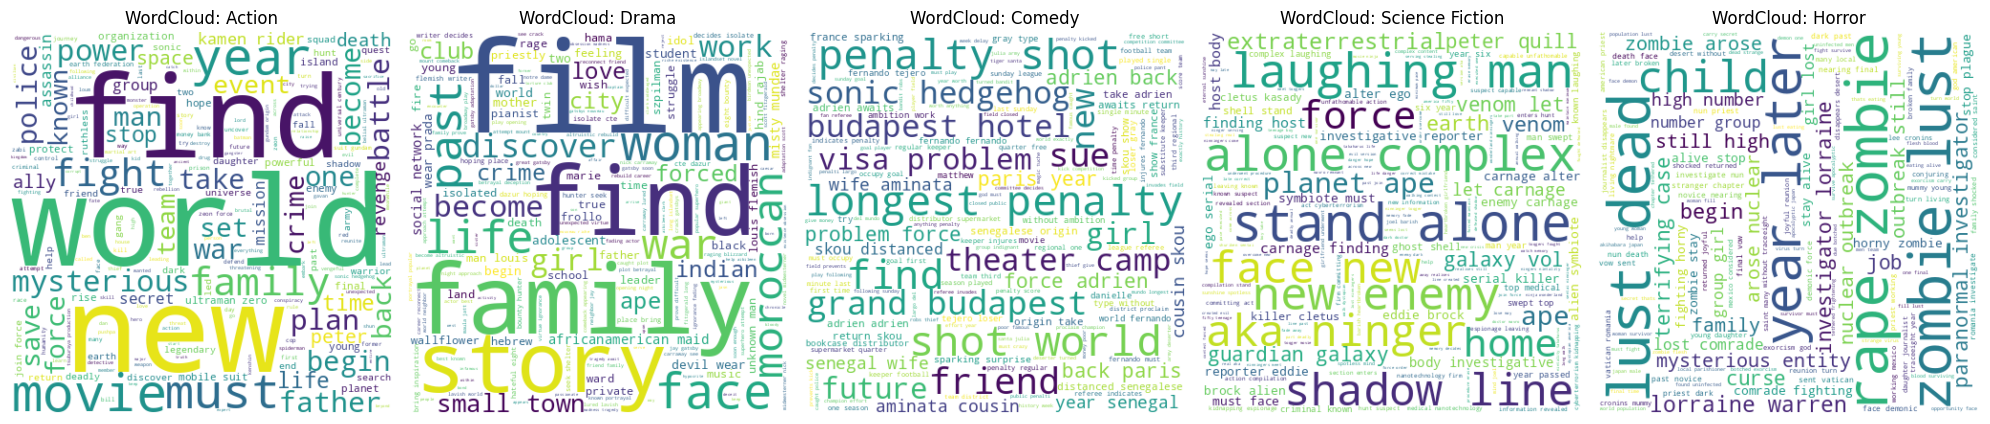

In [ ]:
from wordcloud import WordCloud
# =============================================
# SECTION 2: WordCloud per Genre
# =============================================
genres = df_balanced['selected_genre'].unique()

plt.figure(figsize=(20, 10))
for i, genre in enumerate(genres):
    text = " ".join(df_balanced[df_balanced['selected_genre'] == genre]['cleaned_text'])
    wc = WordCloud(width=400, height=400, background_color='white').generate(text)

    plt.subplot(1, 5, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud: {genre}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# 1. Menyiapkan Data
X = df_balanced['cleaned_text']
y = df_balanced['selected_genre']

# 2. Vektorisasi Teks dengan Custom Stop Words
# Kita tambahkan kata-kata yang terlalu umum atau bias seperti 'family', 'movie', 'new'
custom_stop_words = list(stop_words) + ['family', 'movie', 'new', 'find', 'world']

vectorizer = TfidfVectorizer(
    max_features=1500,
    ngram_range=(1,3),
    stop_words=custom_stop_words
)
X_tfidf = vectorizer.fit_transform(X)

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 4. Latih Model
model = MultinomialNB(alpha=0.1)
model.fit(X_train, y_train)

# 5. Evaluasi
y_pred = model.predict(X_test)
print(f"Akurasi Model: {accuracy_score(y_test, y_pred):.2f}")

# 6. Fungsi untuk Prediksi Teks Baru
def predict_genre(text):
    cleaned_input = clean_text(text)
    tfidf_input = vectorizer.transform([cleaned_input])
    prediction = model.predict(tfidf_input)
    return prediction[0]

# Retest the problematic synopsis
test_text = "A family moves into a remote mansion only to discover that the walls hide a dark, vengeful spirit determined to keep them there forever."
print(f"\nRetested Prediction: '{test_text}'")
print(f"New Result: {predict_genre(test_text)}")

Akurasi Model: 0.85

Retested Prediction: 'A family moves into a remote mansion only to discover that the walls hide a dark, vengeful spirit determined to keep them there forever.'
New Result: Action


In [ ]:
import numpy as np
import pandas as pd

feature_names = vectorizer.get_feature_names_out()

def get_top_keywords(genre_name, n=20):
    if genre_name not in model.classes_:
        return []
    genre_index = np.where(model.classes_ == genre_name)[0][0]
    # Get log probabilities for the specific genre
    log_probs = model.feature_log_prob_[genre_index]
    # Get indices of the top N features
    top_indices = np.argsort(log_probs)[-n:][::-1]
    return [feature_names[i] for i in top_indices]

horror_keywords = get_top_keywords('Horror')
action_keywords = get_top_keywords('Action')

comparison_df = pd.DataFrame({
    'Top Horror Keywords': horror_keywords,
    'Top Action Keywords': action_keywords
})

print("Keyword Analysis: Horror vs Action")
display(comparison_df)

Keyword Analysis: Horror vs Action


,Top Horror Keywords,Top Action Keywords
0,terrifying,force
1,zombie,battle
2,dead,ultraman
3,thing,power
4,stranger,plan
5,far,set
6,warren,sonic
7,lust,organization
8,team,fight
9,take,mysterious


In [ ]:
import numpy as np
import pandas as pd

feature_names = vectorizer.get_feature_names_out()

def get_top_keywords(genre_name, n=20):
    if genre_name not in model.classes_:
        return []
    genre_index = np.where(model.classes_ == genre_name)[0][0]
    # Get log probabilities for the specific genre
    log_probs = model.feature_log_prob_[genre_index]
    # Get indices of the top N features
    top_indices = np.argsort(log_probs)[-n:][::-1]
    return [feature_names[i] for i in top_indices]

horror_keywords = get_top_keywords('Horror')
action_keywords = get_top_keywords('Action')

comparison_df = pd.DataFrame({
    'Top Horror Keywords': horror_keywords,
    'Top Action Keywords': action_keywords
})

print("Keyword Analysis: Horror vs Action")
display(comparison_df)

Keyword Analysis: Horror vs Action


,Top Horror Keywords,Top Action Keywords
0,terrifying,force
1,zombie,battle
2,dead,ultraman
3,thing,power
4,stranger,plan
5,far,set
6,warren,sonic
7,lust,organization
8,team,fight
9,take,mysterious


In [ ]:
from sklearn.model_selection import cross_val_score

# Using the balanced features and labels from the previous steps
# cv=5 splits the data into 5 parts for training and testing
cv_scores = cross_val_score(model, X_tfidf, y, cv=5)

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-Validation Scores: [0.84 0.88 0.85 0.89 0.88]
Average Accuracy: 0.8680
Standard Deviation: 0.0194


In [ ]:
# Identify misclassified samples in the test set
# First, we ensure df_balanced has a clean, unique index for alignment
df_balanced_reset = df_balanced.reset_index(drop=True)

# Re-vectorize and split with the exact same random state to match X_test
X_feat = vectorizer.transform(df_balanced_reset['cleaned_text'])
y_feat = df_balanced_reset['selected_genre']

_, X_test_idx, _, y_test_check = train_test_split(
    df_balanced_reset.index, y_feat, test_size=0.2, random_state=42
)

# Get predictions for the current X_test
y_pred = model.predict(X_test)

# Alignment check: y_test_check should match y_test values
misclassified_mask = y_pred != y_test_check.values

test_df_subset = df_balanced_reset.loc[X_test_idx]

misclassified_df = pd.DataFrame({
    'Title': test_df_subset['title'].values[misclassified_mask],
    'Actual': y_test_check.values[misclassified_mask],
    'Predicted': y_pred[misclassified_mask],
    'Cleaned Text': test_df_subset['cleaned_text'].values[misclassified_mask]
})

print(f"Total Misclassified Samples: {len(misclassified_df)} out of {len(y_test)}")
display(misclassified_df.head(10))

Total Misclassified Samples: 15 out of 100


,Title,Actual,Predicted,Cleaned Text
0,The Usual Suspects,Drama,Action,usual suspect held interrogation room verbal k...
1,Rurouni Kenshin: The Beginning,Action,Horror,rurouni kenshin beginning protector kenshin fe...
2,The Fantastic 4: First Steps,Science Fiction,Action,fantastic first step vibrant backdrop sinspire...
3,The Others,Horror,Action,others grace religious woman life old house ke...
4,The Others,Horror,Action,others grace religious woman life old house ke...
5,The Fantastic Journey,Science Fiction,Action,fantastic journey hour minute edited movie ver...
6,The Bluff,Drama,Action,bluff tranquil life remote island shattered re...
7,The Incredibles,Action,Drama,incredibles bob parr given superhero day log t...
8,Cherry Magic! THE MOVIE,Comedy,Horror,cherry magic movie still able read mind adachi...
9,Guardians of the Galaxy,Action,Science Fiction,guardian galaxy light year earth year abducted...


In [ ]:
target_word = 'spirit'

if target_word in vectorizer.vocabulary_:
    word_idx = vectorizer.vocabulary_[target_word]

    print(f"Feature weights for '{target_word}':")
    for i, category in enumerate(model.classes_):
        # MultinomialNB stores log probabilities in feature_log_prob_
        log_prob = model.feature_log_prob_[i][word_idx]
        print(f"{category}: {log_prob:.4f}")
else:
    print(f"Word '{target_word}' not found in the TF-IDF vocabulary.")

Feature weights for 'spirit':
Action: -6.5328
Comedy: -8.6318
Drama: -8.3367
Horror: -7.0849
Science Fiction: -6.6073


In [ ]:
#DEEP LEARNING WITH TRANSFORMER
!pip install transformers torch

import torch
from transformers import pipeline

# Menggunakan model yang sudah dilatih khusus untuk klasifikasi teks (Zero-Shot Classification)
# Ini memungkinkan kita mencoba tanpa training ulang dari awal
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Contoh kalimat dengan konteks berbeda
sentences = [
    "The team showed great spirit and won the match with a last-minute goal.",
    "A vengeful spirit haunt the old mansion, seeking revenge on the living."
]

candidate_labels = ["Action", "Horror", "Drama"]

for text in sentences:
    result = classifier(text, candidate_labels)
    print(f"Text: {text}")
    print(f"Top Genre: {result['labels'][0]} (Score: {result['scores'][0]:.4f})")
    print("-" * 30)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Text: The team showed great spirit and won the match with a last-minute goal.
Top Genre: Action (Score: 0.7388)
------------------------------
Text: A vengeful spirit haunt the old mansion, seeking revenge on the living.
Top Genre: Horror (Score: 0.6069)
------------------------------


### Panduan Fine-tuning Transformer

Untuk melatih model pada dataset spesifik Anda, kita perlu mengubah data teks menjadi format yang dimengerti oleh model. Berikut adalah langkah-langkahnya menggunakan library `transformers`.

In [ ]:
from transformers import BartForSequenceClassification, BartTokenizer, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
import torch
import pandas as pd
import requests
from google.colab import userdata

# 1. Pastikan df dasar tersedia (Fetch if missing)
if 'df' not in locals():
    API_TOKEN = userdata.get('API_TOKEN')
    DATASET_URL = userdata.get('DATASET_URL')
    response = requests.get(DATASET_URL, params={"token": API_TOKEN, "clean": "true", "limit": 1000})
    df = pd.DataFrame(response.json())
    # Minimal preprocessing for the model to work
    def combine_text(row):
        return f"{str(row['title'])} {str(row['overview'])}"
    df['cleaned_text'] = df.apply(combine_text, axis=1)

# 2. Pastikan df_final dan df_balanced tersedia
if 'df_final' not in locals():
    target_genres = {27: 'Horror', 18: 'Drama', 28: 'Action', 878: 'Science Fiction', 35: 'Comedy'}
    def get_selected_genre(genre_list):
        if isinstance(genre_list, list) and len(genre_list) > 0:
            first_genre = genre_list[0]
            if first_genre in target_genres: return target_genres[first_genre]
        return None
    df['selected_genre'] = df['genre_ids'].apply(get_selected_genre)
    df_final = df.dropna(subset=['selected_genre']).copy()

if 'df_balanced' not in locals():
    target_size = 100
    balanced_list = []
    for genre in df_final['selected_genre'].unique():
        genre_df = df_final[df_final['selected_genre'] == genre]
        resampled_df = resample(genre_df, replace=True, n_samples=target_size, random_state=42)
        balanced_list.append(resampled_df)
    df_balanced = pd.concat(balanced_list)

# 3. Persiapan Label
le = LabelEncoder()
y_encoded = le.fit_transform(df_balanced['selected_genre'])
num_labels = len(le.classes_)

# 4. Inisialisasi Tokenizer dan Model
model_name = "facebook/bart-base"
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# 5. Tokenisasi
def tokenize_function(texts):
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

encodings = tokenize_function(df_balanced['cleaned_text'].tolist())

class MovieDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = MovieDataset(encodings, y_encoded)

# 6. Konfigurasi Training
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_dir='./logs',
    remove_unused_columns=False,
    eval_strategy="no"  # FIXED: evaluation_strategy was renamed to eval_strategy
)

trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset)
print("Model siap untuk dilatih dengan trainer.train()")

[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `3`.


model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.out_proj.weight | MISSING | 
classification_head.dense.bias      | MISSING | 
classification_head.out_proj.bias   | MISSING | 
classification_head.dense.weight    | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Model siap untuk dilatih dengan trainer.train()


In [ ]:
# Pastikan trainer sudah terdefinisi sebelum dijalankan
if 'trainer' in locals():
    print("Memulai proses training...")
    trainer.train()
else:
    print("Error: Objek 'trainer' belum dibuat. Silakan jalankan sel sebelumnya (c3dfbc0f) terlebih dahulu.")

Memulai proses training...


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

```markdown
### Mengapa menggunakan Transformer (BERT/BART)?

1. **Contextual Embeddings**: Berbeda dengan TF-IDF, model ini melihat posisi kata. Kata 'spirit' yang dikelilingi kata 'team' dan 'won' akan dipetakan ke ruang vektor yang berbeda dengan 'spirit' yang dikelilingi kata 'haunt' dan 'mansion'.
2. **Attention Mechanism**: Model memberikan bobot lebih pada kata-kata yang relevan untuk menentukan makna kata tertentu.
3. **Transfer Learning**: Anda bisa menggunakan model yang sudah 'pintar' bahasa Inggris (seperti BERT) dan tinggal melakukan *fine-tuning* sedikit dengan dataset film Anda.
```

### Unsupervised Learning: Topic Modeling (LDA)

Sekarang kita akan mencoba mencari 5 topik dominan dalam dataset tanpa menggunakan label genre. Kita akan menggunakan **Latent Dirichlet Allocation (LDA)**.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.utils import resample
import pandas as pd
import requests
from google.colab import userdata

# 1. Pastikan df tersedia (Fetch jika hilang)
if 'df' not in locals():
    API_TOKEN = userdata.get('API_TOKEN')
    DATASET_URL = userdata.get('DATASET_URL')
    response = requests.get(DATASET_URL, params={"token": API_TOKEN, "clean": "true", "limit": 1000})
    df = pd.DataFrame(response.json())
    # Preprocessing minimal untuk mendapatkan cleaned_text
    def combine_text(row):
        return f"{str(row['title'])} {str(row['overview'])}"
    df['cleaned_text'] = df.apply(combine_text, axis=1)

# 2. Pastikan df_balanced tersedia
if 'df_balanced' not in locals():
    target_genres = {27: 'Horror', 18: 'Drama', 28: 'Action', 878: 'Science Fiction', 35: 'Comedy'}
    def get_selected_genre(genre_list):
        if isinstance(genre_list, list) and len(genre_list) > 0:
            first_genre = genre_list[0]
            if first_genre in target_genres: return target_genres[first_genre]
        return None
    df['selected_genre'] = df['genre_ids'].apply(get_selected_genre)
    df_final = df.dropna(subset=['selected_genre']).copy()

    target_size = 100
    balanced_list = []
    for genre in df_final['selected_genre'].unique():
        genre_df = df_final[df_final['selected_genre'] == genre]
        resampled_df = resample(genre_df, replace=True, n_samples=target_size, random_state=42)
        balanced_list.append(resampled_df)
    df_balanced = pd.concat(balanced_list)

# 3. Jalankan LDA
tf_vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
tf = tf_vectorizer.fit_transform(df_balanced['cleaned_text'])

lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_top = lda_model.fit_transform(tf)

words = tf_vectorizer.get_feature_names_out()
for i, topic in enumerate(lda_model.components_):
    print(f"Topik #{i+1}:")
    top_indices = topic.argsort()[-10:]
    print([words[index] for index in top_indices])
    print("-" * 20)

Topik #1:
['woman', 'stand', 'suspect', 'money', 'new', 'family', 'life', 'young', 'girl', 'year']
--------------------
Topik #2:
['forced', 'guardian', 'family', 'peter', 'war', 'begin', 'search', 'end', 'mysterious', 'world']
--------------------
Topik #3:
['stop', 'planet', 'zombie', 'face', 'year', 'family', 'force', 'deadly', 'ape', 'new']
--------------------
Topik #4:
['world', 'movie', 'existence', 'nun', 'play', 'deceit', 'past', 'known', 'new', 'film']
--------------------
Topik #5:
['new', 'goal', 'time', 'lust', 'fernando', 'young', 'team', 'zombie', 'penalty', 'world']
--------------------


In [ ]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.0 MB/s eta 0:00:00


In [ ]:
import pyLDAvis
import pyLDAvis.lda_model

# Mempersiapkan data visualisasi menggunakan lda_model (pengganti sklearn)
pyLDAvis.enable_notebook()
vis = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer)

# Menampilkan visualisasi
pyLDAvis.display(vis)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Pastikan kita menggunakan dataset unik agar tidak ada duplikasi judul
df_rec = df_balanced.drop_duplicates(subset=['title']).reset_index(drop=True)

# 2. Vektorisasi ulang seluruh dataset untuk rekomendasi
tfidf_rec = TfidfVectorizer(max_features=2000, stop_words='english')
tfidf_matrix = tfidf_rec.fit_transform(df_rec['cleaned_text'])

# 3. Hitung matriks kemiripan (similarity matrix)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def get_recommendations(title, cosine_sim=cosine_sim):
    # Cari indeks film berdasarkan judul
    if title not in df_rec['title'].values:
        return f"Film '{title}' tidak ditemukan dalam dataset."

    idx = df_rec.index[df_rec['title'] == title][0]

    # Ambil skor kemiripan untuk film tersebut dengan semua film lainnya
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Urutkan berdasarkan skor kemiripan tertinggi (kecuali film itu sendiri)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:6] # Ambil 5 teratas

    # Dapatkan indeks film
    movie_indices = [i[0] for i in sim_scores]

    # Kembalikan judul dan genre
    return df_rec[['title', 'selected_genre']].iloc[movie_indices]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Contoh Penggunaan: Cari rekomendasi untuk salah satu film dalam dataset
sample_title = df_rec['title'].iloc[0]
print(f"Rekomendasi untuk film: {sample_title}")
display(get_recommendations(sample_title))

Rekomendasi untuk film: The Shadow's Edge


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,title,selected_genre
175,The Tiger of Santa Julia,Comedy
3,The Presidio,Action
36,The Naked Gun,Action
127,Giant Robo: The Day the Earth Stood Still,Drama
71,Birds of Prey (and the Fantabulous Emancipatio...,Action


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import pandas as pd

# Mencari data film 'The Tiger of Santa Julia' di dataset awal
tiger_data = df[df['title'].str.contains('Tiger of Santa Julia', case=False, na=False)]

display(tiger_data[['title', 'genre_ids', 'selected_genre', 'overview']])

# Cek kata kunci yang sudah dibersihkan
if not tiger_data.empty:
    print(f"\nCleaned Text used by Model:\n{tiger_data['cleaned_text'].iloc[0]}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,title,genre_ids,selected_genre,overview
481,The Tiger of Santa Julia,"[35, 18, 28]",Comedy,An army deserter turned bandit robs from thiev...



Cleaned Text used by Model:
tiger santa julia army deserter turned bandit robs thief give money poor famous caught police pant


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from textblob import TextBlob

def get_sentiment(text):
    # Menghitung polarity (-1 hingga 1)
    return TextBlob(text).sentiment.polarity

def get_subjectivity(text):
    # Menghitung subjectivity (0 hingga 1)
    return TextBlob(text).sentiment.subjectivity

# Menggunakan df_balanced yang sudah kita siapkan sebelumnya
df_balanced['polarity'] = df_balanced['full_text'].apply(get_sentiment)
df_balanced['subjectivity'] = df_balanced['full_text'].apply(get_subjectivity)

# Tampilkan hasil analisis sentimen
display(df_balanced[['title', 'selected_genre', 'polarity', 'subjectivity']].head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,title,selected_genre,polarity,subjectivity
5,The Shadow's Edge,Action,-0.2500,0.500
7,The Wrecking Crew,Action,0.0000,1.000
15,Dhurandhar: The Revenge,Action,-0.4475,0.740
23,The Presidio,Action,-0.1500,0.275
26,The Rip,Action,0.0000,0.000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

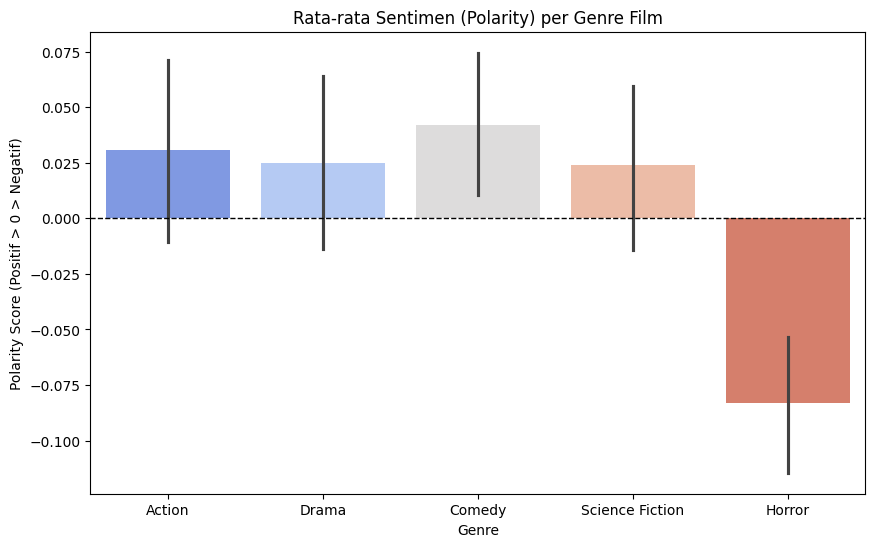

Ringkasan Statistik Sentimen:
selected_genre
Comedy             0.042208
Action             0.030775
Drama              0.025111
Science Fiction    0.023948
Horror            -0.083173
Name: polarity, dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi Rata-rata Polarity per Genre
plt.figure(figsize=(10, 6))
sns.barplot(x='selected_genre', y='polarity', data=df_balanced, palette='coolwarm', hue='selected_genre', legend=False)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Rata-rata Sentimen (Polarity) per Genre Film')
plt.ylabel('Polarity Score (Positif > 0 > Negatif)')
plt.xlabel('Genre')
plt.show()

# Ringkasan Statistik
print("Ringkasan Statistik Sentimen:")
print(df_balanced.groupby('selected_genre')['polarity'].mean().sort_values(ascending=False))